In [2]:
# Titanic Data Analysis
# Exploring passenger survival patterns and demographics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the training data
df = pd.read_csv('../data/train.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

In [4]:
# Get column information
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min      

In [5]:
# Analyze survival by gender

# Get data for males and females
males = df[df['Sex'] == 'male']
females = df[df['Sex'] == 'female']

# Count total males and females
print("Total males:", len(males))
print("Total females:", len(females))

# Count survivors in each group
male_survivors = males[males['Survived'] == 1]
female_survivors = females[females['Survived'] == 1]

print("\nMale survivors:", len(male_survivors))
print("Female survivors:", len(female_survivors))

# Calculate survival rate
male_survival_rate = len(male_survivors) / len(males) * 100
female_survival_rate = len(female_survivors) / len(females) * 100

print("\nMale survival rate: {:.2f}%".format(male_survival_rate))
print("Female survival rate: {:.2f}%".format(female_survival_rate))

Total males: 577
Total females: 314

Male survivors: 109
Female survivors: 233

Male survival rate: 18.89%
Female survival rate: 74.20%


In [6]:
# Analyze survival by age groups

# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 100], 
                         labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60+'])

# Get survival rate by age group
age_survival = df.groupby('AgeGroup')['Survived'].agg(['count', 'sum', 'mean'])
age_survival.columns = ['Total', 'Survivors', 'Survival_Rate']
age_survival['Survival_Rate'] = age_survival['Survival_Rate'] * 100

print("Survival by Age Group:")
print(age_survival)
print("\n")

# Find age group with highest and lowest survival
highest_survival = age_survival['Survival_Rate'].idxmax()
lowest_survival = age_survival['Survival_Rate'].idxmin()

print(f"Age group with highest survival rate: {highest_survival} ({age_survival.loc[highest_survival, 'Survival_Rate']:.2f}%)")
print(f"Age group with lowest survival rate: {lowest_survival} ({age_survival.loc[lowest_survival, 'Survival_Rate']:.2f}%)")

Survival by Age Group:
          Total  Survivors  Survival_Rate
AgeGroup                                 
0-10         64         38      59.375000
11-20       115         44      38.260870
21-30       230         84      36.521739
31-40       155         69      44.516129
41-50        86         33      38.372093
51-60        42         17      40.476190
60+          22          5      22.727273


Age group with highest survival rate: 0-10 (59.38%)
Age group with lowest survival rate: 60+ (22.73%)


In [12]:
# Analyze survival by gender AND age group

# Separate male and female data
males = df[df['Sex'] == 'male']
females = df[df['Sex'] == 'female']

# Create age groups for males and females
male_by_age = males.groupby('AgeGroup')['Survived'].apply(lambda x: (len(x), x.sum(), (x.sum()/len(x)*100)))
female_by_age = females.groupby('AgeGroup')['Survived'].apply(lambda x: (len(x), x.sum(), (x.sum()/len(x)*100)))

print("Male survival by age group (Total, Survivors, %Rate):")
for age_group, (total, survivors, rate) in male_by_age.items():
    print(f"{age_group}: Total={total}, Survivors={int(survivors)}, Rate={rate:.2f}%")

print("\nFemale survival by age group (Total, Survivors, %Rate):")
for age_group, (total, survivors, rate) in female_by_age.items():
    print(f"{age_group}: Total={total}, Survivors={int(survivors)}, Rate={rate:.2f}%")

print("\nGender survival rate comparison by age group:")
print(f"{'Age Group':<12} {'Male %':<10} {'Female %':<10} {'Difference':<10}")
print("-" * 42)
for age_group in male_by_age.index:
    male_rate = male_by_age[age_group][2]
    female_rate = female_by_age[age_group][2]
    diff = female_rate - male_rate
    print(f"{age_group:<12} {male_rate:<10.2f} {female_rate:<10.2f} {diff:<10.2f}")

Male survival by age group (Total, Survivors, %Rate):
0-10: Total=33, Survivors=19, Rate=57.58%
11-20: Total=69, Survivors=10, Rate=14.49%
21-30: Total=149, Survivors=23, Rate=15.44%
31-40: Total=100, Survivors=23, Rate=23.00%
41-50: Total=55, Survivors=12, Rate=21.82%
51-60: Total=28, Survivors=4, Rate=14.29%
60+: Total=19, Survivors=2, Rate=10.53%

Female survival by age group (Total, Survivors, %Rate):
0-10: Total=31, Survivors=19, Rate=61.29%
11-20: Total=46, Survivors=34, Rate=73.91%
21-30: Total=81, Survivors=61, Rate=75.31%
31-40: Total=55, Survivors=46, Rate=83.64%
41-50: Total=31, Survivors=21, Rate=67.74%
51-60: Total=14, Survivors=13, Rate=92.86%
60+: Total=3, Survivors=3, Rate=100.00%

Gender survival rate comparison by age group:
Age Group    Male %     Female %   Difference
------------------------------------------
0-10         57.58      61.29      3.71      
11-20        14.49      73.91      59.42     
21-30        15.44      75.31      59.87     
31-40        23.00  

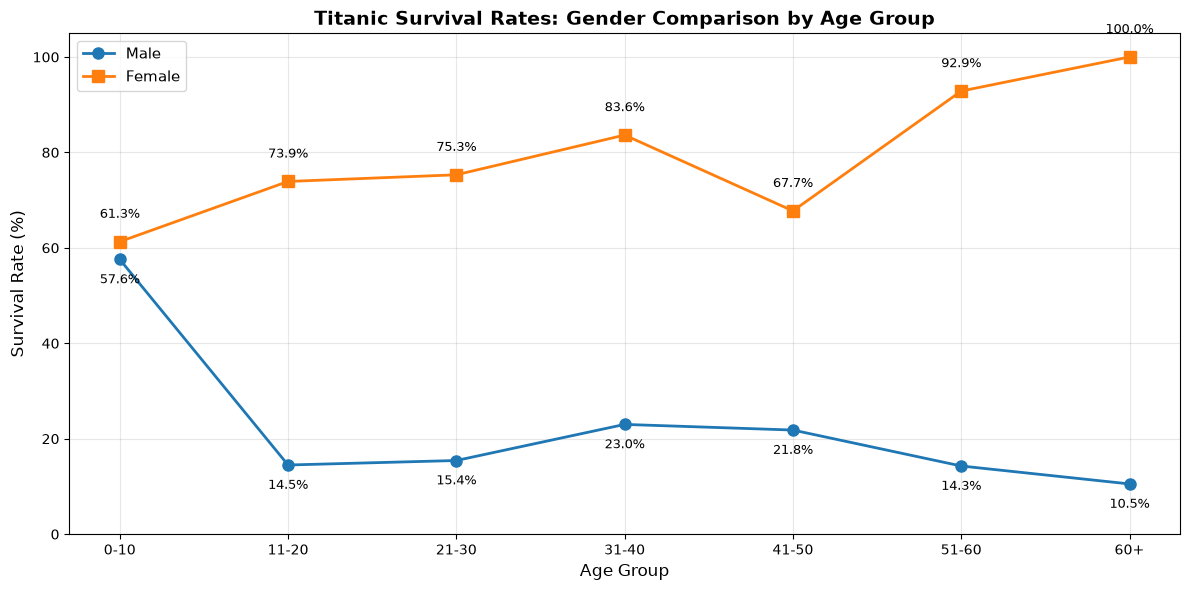


Key Insight: In every age group, women had higher survival rates than men.
The gender gap was largest for elderly passengers (60+): 89.47% difference


In [13]:
# Create visualizations of survival by gender and age

import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(12, 6))

# Extract data for plotting
age_groups = male_by_age.index.tolist()
male_rates = [male_by_age[age][2] for age in age_groups]
female_rates = [female_by_age[age][2] for age in age_groups]

# Create line plot
plt.plot(age_groups, male_rates, marker='o', linewidth=2, markersize=8, label='Male', color='#1f77b4')
plt.plot(age_groups, female_rates, marker='s', linewidth=2, markersize=8, label='Female', color='#ff7f0e')

# Customize the plot
plt.title('Titanic Survival Rates: Gender Comparison by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)

# Add percentage labels on points
for i, age in enumerate(age_groups):
    plt.text(i, male_rates[i] - 5, f'{male_rates[i]:.1f}%', ha='center', fontsize=9)
    plt.text(i, female_rates[i] + 5, f'{female_rates[i]:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey Insight: In every age group, women had higher survival rates than men.")
print("The gender gap was largest for elderly passengers (60+): 89.47% difference")